The purpose of this notebook is to figure out how effective the student teacher model is.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from pathlib import Path
import polars as pl
from birdclef.config import colombia_species_list
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.metrics import classification_report
from pacmap import PaCMAP
import matplotlib.pyplot as plt

from birdclef.mel2vec.loaders import get_word_vectors
from birdclef.mel2vec.student_teacher import get_token_dataframe

In [4]:
shared = Path("~/shared/birdclef").expanduser()
scratch = Path("~/scratch/birdclef/2025v2").expanduser()
tokenizer_path = Path(
    "~/scratch/birdclef/2025v2/mel2vec-v2/tokenizer_pca/n_clusters=16383"
).expanduser()

mfcc_df = (
    pl.scan_parquet(f"{scratch}/mfcc-train/data", low_memory=True)
    .with_columns(
        pl.col("file").str.split("/").list.get(-2).alias("species"),
    )
    .filter(pl.col("species").is_in(colombia_species_list))
)

tokenized = get_token_dataframe(
    mfcc_df,
    tokenizer_path,
    group_by=["species", "file", "start_time"],
    num_workers=8,
).select("species", "token")
tokenized

Tokenizing MFCCs: 100%|██████████| 810781/810781 [01:29<00:00, 9033.44it/s] 


ColumnNotFoundError: token

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'select' <---
SORT BY [col("file"), col("start_time")]
  AGGREGATE[maintain_order: false]
    [col("token").sort_by(by=[col("timestamp")], sort_option=SortMultipleOptions { descending: [false], nulls_last: [false], multithreaded: true, maintain_order: false, limit: None }).alias("tokens")] BY [col("species"), col("file"), col("start_time")]
    FROM
     WITH_COLUMNS:
     [[([(col("timestamp")) floor_div (5.0)]) * (5.0)].alias("start_time"), Series[token], col("file").str.split(["/"]).list.get([dyn int: -1]).alias("file"), col("part")] 
      FILTER col("species").is_in([["socfly1", "strcuc1", … "42113"]])
      FROM
         WITH_COLUMNS:
         [col("file").str.split(["/"]).list.get([dyn int: -2]).alias("species")] 
          Parquet SCAN [/storage/home/hcoda1/8/amiyaguchi3/scratch/birdclef/2025v2/mfcc-train/data/part=0/CSA35133.parquet, ... 28563 other sources] [id: 140736733738112]
          PR

In [ ]:
df = tokenized.collect().to_pandas()
df.shape

(21728, 2)

In [ ]:
# okay now we have to load up our backbone model and drop the last layer
from birdclef.mel2vec.student_teacher import LitStudentModel
from torch import nn

wordvector_path = list(
    (scratch / "mel2vec-v2/word2vec").glob("**/epochs=100/word2vec.wordvectors")
)[0].as_posix()
wordvectors = get_word_vectors(wordvector_path)


model = LitStudentModel.load_from_checkpoint(
    (scratch / "mel2vec-v2/student-teacher" / "best.ckpt").as_posix(),
    wordvectors=wordvectors,
)
# replace the classifier with an identity function
model.classifier = nn.Identity()
model.eval()
model

LitStudentModel(
  (embedding): Embedding(16383, 384)
  (aggregator): Sequential(
    (0): Conv1d(384, 512, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): AdaptiveMaxPool1d(output_size=1)
  )
  (transfer_head): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (classifier): Identity()
  (distillation_loss): KLDivLoss()
)

In [18]:
import torch


def get_embedding(tokens):
    with torch.no_grad():
        x = torch.tensor(tokens).unsqueeze(0)
        embedding = model(x).squeeze(0).numpy()
    return embedding


get_embedding(df.iloc[0].tokens).shape

(512,)

In [24]:
df.tokens.apply(len).describe()

count    21728.000000
mean        37.315031
std          7.799923
min          1.000000
25%         40.000000
50%         40.000000
75%         40.000000
max         40.000000
Name: tokens, dtype: float64

In [25]:
clean = df[df.tokens.apply(len) == 40]
tokens = np.stack(clean.tokens.values)
tokens

array([[13007,  4481, 13007, ..., 15166,  9145,  2923],
       [ 8582,  5167,  3581, ...,  4776, 16192, 11246],
       [ 3034,  6510,  9980, ..., 15479,  6510,  5444],
       ...,
       [  947, 12207,  6240, ..., 13335,  8684,  6240],
       [ 4245,  4245,  4245, ..., 14691,  8340, 12893],
       [11279, 13142, 10376, ..., 10673,   483,  1151]])

In [27]:
with torch.no_grad():
    X = model(torch.from_numpy(tokens)).cpu().numpy()
X

array([[-0.18245848,  2.9827251 , -0.19461924, ..., -0.19103073,
        -0.12181795, -0.6424614 ],
       [-0.18245848, -0.18525358, -0.19461924, ..., -0.19103073,
        -0.12181795,  0.23165396],
       [-0.18245848, -1.1229141 , -0.19461924, ..., -0.19103073,
        -0.12181795, -0.289148  ],
       ...,
       [-0.18245848,  0.59974366, -0.19461924, ..., -0.19103073,
        -0.12181795,  0.93358725],
       [-0.18245848,  0.432933  , -0.19461924, ..., -0.19103073,
        -0.12181795, -0.06862401],
       [-0.18245848,  0.7317125 , -0.19461924, ..., -0.19103073,
        -0.12181795,  0.78513354]], dtype=float32)

In [30]:
y = clean["species"].values
le = LabelEncoder()
y = le.fit_transform(y)
# stratify the split by species
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model = LogisticRegression(max_iter=1000, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_micro = f1_score(y_test, y_pred, average="micro")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")

report = classification_report(
    y_test, y_pred, labels=np.arange(len(le.classes_)), target_names=le.classes_
)
print(report)

F1 Macro: 0.2507
F1 Micro: 0.3278
              precision    recall  f1-score   support

     1192948       0.17      0.12      0.14        16
     1462737       0.36      0.48      0.41        27
       41778       0.20      0.12      0.15         8
       42113       0.00      0.00      0.00         0
       47067       0.00      0.00      0.00         2
       52884       0.44      0.50      0.47       232
      555086       0.25      0.23      0.24        47
       65344       0.17      0.07      0.10        15
       67252       0.43      0.41      0.42        44
     blhpar1       0.38      0.13      0.20       157
      blkvul       0.39      0.25      0.30        69
     butsal1       0.29      0.28      0.29       398
      cattyr       0.29      0.11      0.16       141
     eardov1       0.30      0.28      0.29        83
      neocor       0.30      0.27      0.28        82
     savhaw1       0.00      0.00      0.00        37
     socfly1       0.33      0.48      0.39    

/storage/home/hcoda1/8/amiyaguchi3/clef/birdclef-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/storage/home/hcoda1/8/amiyaguchi3/clef/birdclef-2025/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shap

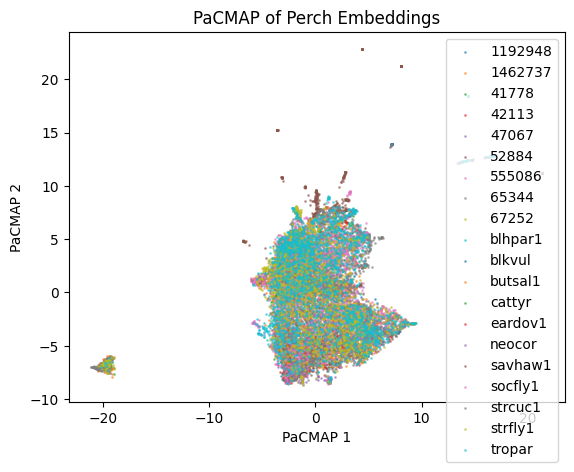

In [31]:
def plot_pacman(X, y, le, title):
    z = PaCMAP().fit_transform(X)
    for i, species in enumerate(le.classes_):
        plt.scatter(z[y == i, 0], z[y == i, 1], label=species, alpha=0.5, s=1)
    plt.legend()
    plt.xlabel("PaCMAP 1")
    plt.ylabel("PaCMAP 2")
    plt.title(title)


plot_pacman(X, y, le, "PaCMAP of Perch Embeddings")

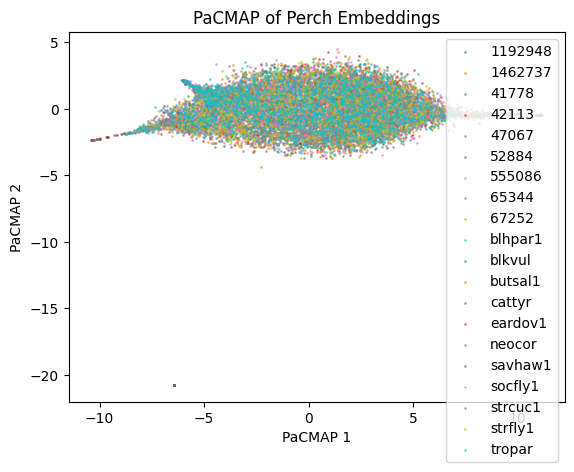

In [32]:
plot_pacman(tokens, y, le, "PaCMAP of Perch Embeddings")